In [1]:
import numpy as np
import pandas as pd
import pickle
# train VAE to learn the dynamic of inventory control problem
# s: inventory level, a: order quantity, r: reward, o: demand
# N = 10, k = 1, c = 2, z = 2, p = 4, lambda = 5.
# 0 \le a \le N
# o ~ Poisson(lambda)
# s' = max(0, min(N, s + a) - o)
# r = -k * 1(a>0) - c * (min(N, s + a) - s) - z * s + p * min(o, s+a)

class Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a, a_min=None, a_max=self.N) - o, 0, None)
        # s1 = np.array(s1)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done


class Noisy_Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a + np.random.normal(0, 1, (1,)), a_min=None, a_max=self.N) - o, 0, None)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a) + np.random.normal(1, 1, (1,)) # some positive bias
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done

In [2]:
env = Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)
noisy_env = Noisy_Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)

In [407]:
# generate 1000 trajectories
_states = []
_actions = []
_rewards = []
_next_states = []
_dones = []
for _ in range(3000):
    s = env.reset()
    trajectory = []
    for h in range(env.H):
        a = np.random.uniform(0, 10, (1,))
        s, a, r, s1, done = env.step(s, a, h)
        _states.append(s)
        _actions.append(a)
        _rewards.append(r)
        _next_states.append(s1)
        _dones.append(done)
        s = s1

In [238]:
# convert to dictionary
import pickle
import os

data = {
    'observations': np.array(_states),
    'actions': np.array(_actions),
    'rewards': np.array(_rewards),
    'next_observations': np.array(_next_states),
    'terminals': np.array(_dones)
}

# save as npz file
np.savez('data/inventory_data.npz', **data)

In [298]:
# load the data
data = dict(np.load('data/inventory_data.npz', allow_pickle=True))
observations = data['observations']
actions = data['actions']
rewards = data['rewards']
next_observations = data['next_observations']
terminals = data['terminals']
print(observations.shape)
print(actions.shape)
print(rewards.shape)
print(next_observations.shape)
print(terminals.shape)

(60000, 1)
(60000, 1)
(60000,)
(60000, 1)
(60000,)


In [41]:
import collections
def sequence_dataset(data, **kwargs):
    N = data['rewards'].shape[0]
    print("----------------------")
    print(N)
    data_ = collections.defaultdict(list)

    # The newer version of the dataset adds an explicit
    # timeouts field. Keep old method for backwards compatability.
    use_timeouts = False
    if 'timeouts' in data:
        use_timeouts = True

    episode_step = 0
    for i in range(N):
        done_bool = bool(data['terminals'][i])
        if use_timeouts:
            final_timestep = data['timeouts'][i]
        else:
            final_timestep = (episode_step == 20 - 1)

        for k in data:
            if k.find("metadata")==-1:
                print(k)
                data_[k].append(data[k][i])
        print("----------------------------")

        episode_step += 1
        if done_bool or final_timestep:
            episode_step = 0
            episode_data = {}
            for k in data_:
                episode_data[k] = np.array(data_[k])
            yield episode_data
            data_ = collections.defaultdict(list)

In [42]:
def port_d4rl_data(d4rl_data, obs_mean, obs_std, rew_mean, rew_std, max_step=1000):
        d4rl_data = [_d for _d in d4rl_data] # convert generator to list
        print(len(d4rl_data))
        print(d4rl_data[0])
        return d4rl_data

In [ ]:
d4rl_data = port_d4rl_data(sequence_dataset(data), obs_mean=0, obs_std=1, rew_mean=0, rew_std=1)

In [4]:
# define 10 policies to evaluate
# several [a, b] uniform policies
# several (s, S) policies
# several N(mu, sigma^2) policies
from scipy.stats import norm

class uniform_policy(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def act(self, s):
        a = np.random.randint(self.a, self.b+1, (1,))
        return a
    
    def prob(self, s, a):
        return 1.0 / (self.b - self.a + 1)

class sS_policy(object):
    def __init__(self, s, S):
        self.a = s
        self.b = S

    def act(self, s):
        if s < self.a:
            a = self.b - s
        else:
            a = np.random.uniform(0, 0, (1,))
        return a

class normal_policy(object):
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def act(self, s):
        # sample from 0 to 10, with the probability proportional to exp(-|x-mu+s|)
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        a = np.random.choice(range(11), p=prob)
        return a
    
    def prob(self, s, a):
        # calculate the probability of a given s and a
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        return prob[int(a)]
        # prob = 1.0 / (self.sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((a - self.mu + s) / self.sigma) ** 2)
        # # reweight for truncated normal distribution
        # # compute P(0 <= X <= 10)
        # integral_0_10 = norm.cdf(10, loc=self.mu-s, scale=self.sigma) - norm.cdf(0, loc = self.mu-s, scale=self.sigma)
        # return prob / integral_0_10


class approximate_uniform_policy(object):
    def __init__(self, a, b, eps):
        self.a = a
        self.b = b
        self.eps = eps
        self.idx_add_eps = range(5)
        self.idx_sub_eps = range(5, 10)
        self.prob_list = [1/11 for _ in range(11)]
        for i in self.idx_add_eps:
            self.prob_list[i] = self.prob_list[i] + self.eps
        for i in self.idx_sub_eps:
            self.prob_list[i] = self.prob_list[i] - self.eps

    def act(self, s):
        a = np.random.choice(range(11), p=self.prob_list, size=(1,))
        return a
    
    def prob(self, s, a):
        return self.prob_list[int(a)]

In [13]:
result = pd.DataFrame(columns=['delta', 'iter', 'V_PPI', 'lower_bound', 'upper_bound'])

In [14]:
pi_u_0_10 = uniform_policy(0, 10)
pi_u_0_5 = uniform_policy(0, 5)
pi_u_3_8 = uniform_policy(3, 8)
pi_u_0_0 = uniform_policy(0, 0)
pi_u_6_6 = uniform_policy(6, 6)

pi_sS_3_10 = sS_policy(3, 10)
pi_sS_3_6 = sS_policy(3, 6)
pi_sS_7_10 = sS_policy(7, 10)
pi_sS_1_5 = sS_policy(1, 5)
pi_sS_5_8 = sS_policy(5, 8)

pi_n_10_1 = normal_policy(5.5, 1)

pi_b = pi_u_0_10

# generate 500 trajectories from pi_u_0_10, saved as training dataset
gamma = 0.9
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(400):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/train_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

# generate 100 trajectories from pi_u_0_10, saved as calibration dataset
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(100):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/cal_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

In [16]:
for delta in np.linspace(0.06, 0.1, 4, endpoint=False):
    approximate_pi_u_0_10 = approximate_uniform_policy(0, 10, delta)
    pi_e = approximate_pi_u_0_10

    for iter in range(10):
        # generate 10000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
        train_trajectories = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
        _trajectories = []
        _actions_trajectories = []
        _rewards = []
        for i in range(len(train_trajectories['trajectories'])):
            s0 = train_trajectories['trajectories'][i][0]
            for _ in range(100):
                s = s0
                reward = 0
                trajectory = []
                action_trajectory = []
                for h in range(env.H):
                    a = pi_b.act(s)
                    s, a, r, s1, done = noisy_env.step(s, a, h)
                    trajectory.append(s)
                    action_trajectory.append(a)
                    reward += r * (gamma ** h)
                    s = s1
                _trajectories.append(trajectory)
                _actions_trajectories.append(action_trajectory)
                _rewards.append(reward)
        # convert to dictionary
        data = {
            'trajectories': np.array(_trajectories),
            'actions': np.array(_actions_trajectories),
            'rewards': np.array(_rewards)
        }
        # save as 0_o.pkl
        with open('saved_trajectories/train_0_diff.pkl', 'wb') as f:
            pickle.dump(data, f)

        # generate 2000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
        cal_trajectories = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))
        _trajectories = []
        _actions_trajectories = []
        _rewards = []
        for i in range(len(cal_trajectories['trajectories'])):
            s0 = cal_trajectories['trajectories'][i][0]
            for _ in range(100):
                s = s0
                reward = 0
                trajectory = []
                action_trajectory = []
                for h in range(env.H):
                    a = pi_b.act(s)
                    s, a, r, s1, done = noisy_env.step(s, a, h)
                    trajectory.append(s)
                    action_trajectory.append(a)
                    reward += r * (gamma ** h)
                    s = s1
                _trajectories.append(trajectory)
                _actions_trajectories.append(action_trajectory)
                _rewards.append(reward)
        # convert to dictionary
        data = {
            'trajectories': np.array(_trajectories),
            'actions': np.array(_actions_trajectories),
            'rewards': np.array(_rewards)
        }
        # save as 0_o.pkl
        with open('saved_trajectories/cal_0_diff.pkl', 'wb') as f:
            pickle.dump(data, f)

        pi_b_diff = pickle.load(open("saved_trajectories/train_0_diff.pkl", "rb"))
        pi_b_0 = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))

        pi_b_diff_trajs = pi_b_diff['trajectories']
        pi_b_diff_actions = pi_b_diff['actions']
        pi_b_diff_rewards = pi_b_diff['rewards']
        pi_b_0_trajs = pi_b_0['trajectories']
        pi_b_0_actions = pi_b_0['actions']
        pi_b_0_rewards = pi_b_0['rewards']
            
        s0_pairs = []
        for i in range(len(pi_b_0_trajs)):
            for j in range(len(pi_b_diff_trajs)):
                if pi_b_0_trajs[i][0] == pi_b_diff_trajs[j][0]:
                    s0_pairs.append((i, j))

        E_diff_rewards = np.zeros(len(pi_b_0_trajs))
        for i, j in s0_pairs:
            diff = pi_b_0_rewards[i] - pi_b_diff_rewards[j]
            E_diff_rewards[i] += diff
        E_diff_rewards = E_diff_rewards / (len(pi_b_diff_trajs)/len(pi_b_0_trajs))

        eps_s = 0.3
        eps_r = 0.3

        matching_pairs = []
        for i in range(len(pi_b_0_trajs)):
            for i2, j2 in s0_pairs:
                if abs(pi_b_0_trajs[i][0] - pi_b_0_trajs[i2][0]) < eps_s and \
                    abs(E_diff_rewards[i] - (pi_b_0_rewards[i2] - pi_b_diff_rewards[j2])) < eps_r:
                    matching_pairs.append((i, i2, j2)) # (i2, j2) can be used to calculate the weights for (i, E_diff_rewards[i])
        
        weights = []
        for i in range(len(pi_b_0_trajs)):
            w = 0
            n = 0
            for i1, i2, j2 in matching_pairs:
                w1 = 1
                if i == i1:
                    for t in range(len(pi_b_0_trajs[i2])):
                        w1 *= pi_e.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) * pi_e.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t]) / \
                            pi_b.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / pi_b.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t])
                        # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / \
                        #     pi_u_0_10.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) # old weights
                    w += w1
                    n += 1
            assert n > 0
            weights.append(w/n)

        weights = np.array(weights, dtype=np.float32)
        delta_reward = np.array(E_diff_rewards, dtype=np.float32)
        delta_reward_sorted = np.sort(delta_reward)
        weights_sorted = weights[np.argsort(delta_reward)]

        pi_b_diff = pickle.load(open("saved_trajectories/cal_0_diff.pkl", "rb"))
        pi_b_0 = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))

        pi_b_diff_trajs = pi_b_diff['trajectories']
        pi_b_diff_actions = pi_b_diff['actions']
        pi_b_diff_rewards = pi_b_diff['rewards']
        pi_b_0_trajs = pi_b_0['trajectories']
        pi_b_0_actions = pi_b_0['actions']
        pi_b_0_rewards = pi_b_0['rewards']

        s0_pairs = []
        for i in range(len(pi_b_0_trajs)):
            for j in range(len(pi_b_diff_trajs)):
                if pi_b_0_trajs[i][0] == pi_b_diff_trajs[j][0]:
                    s0_pairs.append((i, j))

        def w(x, y):
            matching_pairs = []
            for i1, j1 in s0_pairs:
                if abs(pi_b_0_trajs[i1][0] - x) < eps_s and \
                    abs((pi_b_0_rewards[i1] - pi_b_diff_rewards[j1]) - y) < eps_r:
                    matching_pairs.append((i1, j1))
            w = 0
            n = len(matching_pairs)
            for i, j in matching_pairs:
                w1 = 1
                for t in range(len(pi_b_0_trajs[i])):
                    w1 *= pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) * pi_b.prob(pi_b_diff_trajs[j][t], pi_b_diff_actions[j][t]) / \
                        pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_b.prob(pi_b_diff_trajs[j][t], pi_b_diff_actions[j][t])
                    # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / \
                    #     pi_u_0_10.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
                w += w1
            if n > 0:
                return w/n
            else:
                return -1
            
        start_s = 5
        # construct conformal prediction interval with level alpha
        alpha = 0.05
        # search for valid y from -10 to 10
        y_list = np.linspace(-10, 10, 100)
        CP_1_y = []
        for y in y_list:
            w_ = w(start_s, y)
            if w_ > 0:
                # check whether y is in (alpha/2, 1-alpha/2) quantile of F
                new_weights = np.append(weights_sorted, w_)
                normalized_weights = new_weights / np.sum(new_weights)
                # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
                low_level = 0
                high_level = 0
                low_q = 0
                high_q = 0
                for i in range(len(delta_reward_sorted)):
                    low_level += normalized_weights[i]
                    if low_level >= alpha/2:
                        low_q = delta_reward_sorted[i-1]
                        break
                for i in range(len(delta_reward_sorted)):
                    high_level += normalized_weights[i]
                    if high_level >= 1 - alpha/2:
                        high_q = delta_reward_sorted[i-1]
                        break
                print("low_q: ", low_q)
                print("high_q: ", high_q)
                break
        
        # generate 500 trajectories from pi_n_10_1, saved as first_term
        _trajectories = []
        _actions_trajectories = []
        _rewards = []
        for _ in range(500):
            s = np.array(start_s).reshape(1,)
            reward = 0
            trajectory = []
            action_trajectory = []
            for h in range(env.H):
                a = pi_e.act(s)
                s, a, r, s1, done = noisy_env.step(s, a, h)
                trajectory.append(s)
                action_trajectory.append(a)
                reward += r * (gamma ** h)
                s = s1
            _trajectories.append(trajectory)
            _actions_trajectories.append(action_trajectory)
            _rewards.append(reward)

        # convert to dictionary
        import pickle
        data = {
            'trajectories': np.array(_trajectories),
            'actions': np.array(_actions_trajectories),
            'rewards': np.array(_rewards)
        }

        # save as 9_first_term.pkl
        with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
            pickle.dump(data, f)

        pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

        pi_e_diff_trajs = pi_e_diff['trajectories']
        pi_e_diff_actions = pi_e_diff['actions']
        pi_e_diff_rewards = pi_e_diff['rewards']

        hat_V_pi_e = np.mean(pi_e_diff_rewards)

        # CP = (hat_V_pi_e + low_q, hat_V_pi_e + high_q)

        # save a row to result
        result = pd.concat([result, pd.DataFrame({'delta': [delta], 'iter': [iter], 'V_PPI': [hat_V_pi_e], 'lower_bound': [hat_V_pi_e + low_q], 'upper_bound': [hat_V_pi_e + high_q]})], ignore_index=True)
        print(f"delta: {delta}, iter: {iter}, V_PPI: {hat_V_pi_e}, lower_bound: {hat_V_pi_e + low_q}, upper_bound: {hat_V_pi_e + high_q}")

result.to_csv('saved_trajectories/result_per_state_5.csv', index=False)

low_q:  -23.72011
high_q:  6.985296
delta: 0.06, iter: 0, V_PPI: 38.4995753707939, lower_bound: 14.779465431218703, upper_bound: 45.48487114334639
low_q:  -24.541912
high_q:  2.2633169
delta: 0.06, iter: 1, V_PPI: 38.674839280178986, lower_bound: 14.132927201321564, upper_bound: 40.938156149914704
low_q:  -32.43303
high_q:  0.48367026
delta: 0.06, iter: 2, V_PPI: 38.770005801690495, lower_bound: 6.336976626885807, upper_bound: 39.25367606617299
low_q:  -24.197931
high_q:  0.39189884
delta: 0.06, iter: 3, V_PPI: 38.70677275801394, lower_bound: 14.508841468341089, upper_bound: 39.09867159867976
low_q:  -27.801407
high_q:  11.254467
delta: 0.06, iter: 4, V_PPI: 38.53528093509983, lower_bound: 10.733874074748265, upper_bound: 49.789747945597874
low_q:  -31.230106
high_q:  6.139565
delta: 0.06, iter: 5, V_PPI: 38.55642244243606, lower_bound: 7.326316088676293, upper_bound: 44.69598743343337
low_q:  -25.942596
high_q:  9.835863
delta: 0.06, iter: 6, V_PPI: 38.6437693110354, lower_bound: 12.7

In [5]:
pi_u_0_10 = uniform_policy(0, 10)
pi_u_0_5 = uniform_policy(0, 5)
pi_u_3_8 = uniform_policy(3, 8)
pi_u_0_0 = uniform_policy(0, 0)
pi_u_6_6 = uniform_policy(6, 6)

pi_sS_3_10 = sS_policy(3, 10)
pi_sS_3_6 = sS_policy(3, 6)
pi_sS_7_10 = sS_policy(7, 10)
pi_sS_1_5 = sS_policy(1, 5)
pi_sS_5_8 = sS_policy(5, 8)

pi_n_10_1 = normal_policy(5.5, 1)

pi_b = pi_u_0_10
pi_e = approximate_uniform_policy(0, 10, 0.08)

In [138]:
# generate 500 trajectories from pi_u_0_10, saved as training dataset
gamma = 0.9
_trajectories = []
_actions_trajectories = []
_rewards_trajectories = []
_rewards = []
for _ in range(400):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    reward_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward_trajectory.append(r)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards_trajectories.append(reward_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions_trajectories': np.array(_actions_trajectories),
    'rewards_trajectories': np.array(_rewards_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/train_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

In [139]:
# generate 100 trajectories from pi_u_0_10, saved as calibration dataset
_trajectories = []
_actions_trajectories = []
_rewards_trajectories = []
_rewards = []
for _ in range(100):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    reward_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward_trajectory.append(r)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards_trajectories.append(reward_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions_trajectories': np.array(_actions_trajectories),
    'rewards_trajectories': np.array(_rewards_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/cal_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

In [141]:
# use a neural network to learn the transition and reward
import torch
import torch.nn as nn
import torch.optim as optim

class TransitionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(TransitionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        mu = x[:, :1]
        sigma = x[:, 1:2]
        return mu, sigma # assume normal distribution for transition

class RewardModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RewardModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x # assume deterministic reward
    
# train the two models using train_0_o.pkl
train_0_o = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
train_0_o_trajs = train_0_o['trajectories']
train_0_o_actions = train_0_o['actions_trajectories']
train_0_o_rewards = train_0_o['rewards_trajectories']

# make batch data (s, a, r, s1)
batch_data = []
for i in range(len(train_0_o_trajs)):
    for t in range(len(train_0_o_trajs[i]) - 1):
        s = train_0_o_trajs[i][t]
        a = train_0_o_actions[i][t]
        r = train_0_o_rewards[i][t]
        s1 = train_0_o_trajs[i][t + 1]
        batch_data.append((s, a, r, s1))


In [142]:
T = TransitionModel(input_dim=2, hidden_dim=64, output_dim=2)
R = RewardModel(input_dim=3, hidden_dim=64, output_dim=1)

In [143]:
optimizer_T = optim.Adam(T.parameters(), lr=0.001)
optimizer_R = optim.Adam(R.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 1000
batch_size = 64

In [144]:
for epoch in range(num_epochs):
    # shuffle the data
    np.random.shuffle(batch_data)
    for i in range(0, len(batch_data), batch_size):
        batch = batch_data[i:i + batch_size]
        s = torch.tensor([b[0] for b in batch], dtype=torch.float32)
        a = torch.tensor([b[1] for b in batch], dtype=torch.float32)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        s1 = torch.tensor([b[3] for b in batch], dtype=torch.float32)

        # train transition model
        optimizer_T.zero_grad()
        mu, sigma = T(torch.cat((s, a), dim=1))
        # print(mu.shape, sigma.shape)
        # sample from N(mu, sigma)
        s1_pred = torch.randn(s1.shape) * sigma + mu
        loss_T = criterion(s1_pred, s1)
        loss_T.backward()
        optimizer_T.step()

        # train reward model
        optimizer_R.zero_grad()
        r_pred = R(torch.cat((s, a, s1), dim=1)).squeeze()
        loss_R = criterion(r_pred, r)
        loss_R.backward()
        optimizer_R.step()

    if epoch % 100 == 0:
        # print(f's: {s}, a: {a}, r: {r}, s1: {s1}')
        print(f'Epoch [{epoch}/{num_epochs}], Loss T: {loss_T.item():.4f}, Loss R: {loss_R.item():.4f}')

Epoch [0/1000], Loss T: 1.3253, Loss R: 12.5641
Epoch [100/1000], Loss T: 0.7287, Loss R: 0.0006
Epoch [200/1000], Loss T: 0.6406, Loss R: 0.0001
Epoch [300/1000], Loss T: 0.5737, Loss R: 0.0000
Epoch [400/1000], Loss T: 0.5338, Loss R: 0.0000
Epoch [500/1000], Loss T: 0.8488, Loss R: 0.0000
Epoch [600/1000], Loss T: 0.7813, Loss R: 0.0000
Epoch [700/1000], Loss T: 0.4731, Loss R: 0.0001
Epoch [800/1000], Loss T: 0.7897, Loss R: 0.0001
Epoch [900/1000], Loss T: 1.2165, Loss R: 0.0001


In [200]:
# save the models
torch.save(T.state_dict(), 'saved_model/transition_model.pth')
torch.save(R.state_dict(), 'saved_model/reward_model.pth')

In [294]:
# generate 10000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
train_trajectories = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(train_trajectories['trajectories'])):
    s0 = train_trajectories['trajectories'][i][0]
    for _ in range(30):
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_b.act(s)
            trajectory.append(s)
            action_trajectory.append(a)
            s = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            a = torch.tensor(a, dtype=torch.float32).unsqueeze(0)
            mu, sigma = T(torch.cat((s, a), dim=1))
            s1 = torch.randn(s.shape) * sigma + mu
            r = R(torch.cat((s, a, s1), dim=1)).squeeze()
            r = r.detach().numpy()
            reward += r * (gamma ** h)
            s1 = s1.detach().numpy().reshape(1,)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions_trajectories': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/train_0_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

In [295]:
# generate 2000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
cal_trajectories = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(cal_trajectories['trajectories'])):
    s0 = cal_trajectories['trajectories'][i][0]
    for _ in range(100):
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_b.act(s)
            # print(s, a)
            trajectory.append(s)
            action_trajectory.append(a)
            s = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
            a = torch.tensor(a, dtype=torch.float32).unsqueeze(0)
            mu, sigma = T(torch.cat((s, a), dim=1))
            s1 = torch.randn(s.shape) * sigma + mu
            r = R(torch.cat((s, a, s1), dim=1)).squeeze()
            r = r.detach().numpy()
            reward += r * (gamma ** h)
            s1 = s1.detach().numpy().reshape(1,)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions_trajectories': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('saved_trajectories/cal_0_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

In [11]:
# # build a generator for data augmentation
# def noise_augmentation_generator(data, noise_level=0.1):
#     _trajectories = []
#     _actions_trajectories = []
#     _rewards = []
#     num = len(data['trajectories'])
#     for i in range(num):
#         # add noise to the trajectories (from the second time step)
#         traj = data['trajectories'][i]
#         traj[1:] = traj[1:] + np.random.normal(0, noise_level, traj[1:].shape)
#         _trajectories.append(traj)
#         # add noise to the actions
#         action_traj = data['actions'][i]
#         action_traj = action_traj + np.random.normal(0, noise_level, action_traj.shape)
#         _actions_trajectories.append(action_traj)
#         # add noise to the rewards
#         reward_traj = data['rewards'][i]
#         reward_traj = reward_traj + np.random.normal(0, noise_level, reward_traj.shape)
#         _rewards.append(reward_traj)
    
#     return _trajectories, _actions_trajectories, _rewards

# train_0_o = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
# _trajs = []
# _actions = []
# _rewards = []
# for _ in range(100):
#     trajs, actions, rewards = noise_augmentation_generator(train_0_o, noise_level=0.1)
#     _trajs.extend(trajs)
#     _actions.extend(actions)
#     _rewards.extend(rewards)
# # convert to dictionary
# train_0_diff = {
#     'trajectories': np.array(_trajs),
#     'actions': np.array(_actions),
#     'rewards': np.array(_rewards)
# }
# # save as 0_diff.pkl
# with open('saved_trajectories/train_0_diff.pkl', 'wb') as f:
#     pickle.dump(train_0_diff, f)

In [ ]:
# cal_0_o = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))
# _trajs = []
# _actions = []
# _rewards = []
# for _ in range(100):
#     trajs, actions, rewards = noise_augmentation_generator(cal_0_o, noise_level=0.1)
#     _trajs.extend(trajs)
#     _actions.extend(actions)
#     _rewards.extend(rewards)
# # convert to dictionary
# cal_0_diff = {
#     'trajectories': np.array(_trajs),
#     'actions': np.array(_actions),
#     'rewards': np.array(_rewards)
# }
# # save as 0_diff.pkl
# with open('saved_trajectories/cal_0_diff.pkl', 'wb') as f:
#     pickle.dump(cal_0_diff, f)

In [1097]:
# # generate 10000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
# train_trajectories = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))
# _trajectories = []
# _actions_trajectories = []
# _rewards = []
# for i in range(len(train_trajectories['trajectories'])):
#     s0 = train_trajectories['trajectories'][i][0]
#     for _ in range(100):
#         s = s0
#         reward = 0
#         trajectory = []
#         action_trajectory = []
#         for h in range(env.H):
#             a = pi_e.act(s)
#             s, a, r, s1, done = noisy_env.step(s, a, h)
#             trajectory.append(s)
#             action_trajectory.append(a)
#             reward += r * (gamma ** h)
#             s = s1
#         _trajectories.append(trajectory)
#         _actions_trajectories.append(action_trajectory)
#         _rewards.append(reward)
# # convert to dictionary
# data = {
#     'trajectories': np.array(_trajectories),
#     'actions': np.array(_actions_trajectories),
#     'rewards': np.array(_rewards)
# }
# # save as 0_o.pkl
# with open('saved_trajectories/train_0_diff.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [1098]:
# # generate 2000 trajectories from pi_u_0_10, conditioned on the initial state of each traj in 0_o.pkl
# cal_trajectories = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))
# _trajectories = []
# _actions_trajectories = []
# _rewards = []
# for i in range(len(cal_trajectories['trajectories'])):
#     s0 = cal_trajectories['trajectories'][i][0]
#     for _ in range(100):
#         s = s0
#         reward = 0
#         trajectory = []
#         action_trajectory = []
#         for h in range(env.H):
#             a = pi_e.act(s)
#             s, a, r, s1, done = noisy_env.step(s, a, h)
#             trajectory.append(s)
#             action_trajectory.append(a)
#             reward += r * (gamma ** h)
#             s = s1
#         _trajectories.append(trajectory)
#         _actions_trajectories.append(action_trajectory)
#         _rewards.append(reward)
# # convert to dictionary
# data = {
#     'trajectories': np.array(_trajectories),
#     'actions': np.array(_actions_trajectories),
#     'rewards': np.array(_rewards)
# }
# # save as 0_o.pkl
# with open('saved_trajectories/cal_0_diff.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [6]:
pi_b_diff = pickle.load(open("saved_trajectories/train_0_diff.pkl", "rb"))
pi_b_0 = pickle.load(open("saved_trajectories/train_0_o.pkl", "rb"))

pi_b_diff_trajs = pi_b_diff['trajectories']
pi_b_diff_actions = pi_b_diff['actions_trajectories']
pi_b_diff_rewards = pi_b_diff['rewards']
pi_b_0_trajs = pi_b_0['trajectories']
pi_b_0_actions = pi_b_0['actions_trajectories']
pi_b_0_rewards = pi_b_0['rewards']

# merge the two datasets
pi_b_whole_trajs = np.concatenate((pi_b_0_trajs, pi_b_diff_trajs), axis=0)
pi_b_whole_actions = np.concatenate((pi_b_0_actions, pi_b_diff_actions), axis=0)
pi_b_whole_rewards = np.concatenate((pi_b_0_rewards, pi_b_diff_rewards), axis=0)

In [7]:
eps_s = 0.3
eps_r = 0.3

matching_pairs = []
for m in range(len(pi_b_0_trajs)):
    for n in range(len(pi_b_0_trajs)):
        if abs(pi_b_0_trajs[m][0] - pi_b_0_trajs[n][0]) < eps_s and \
            abs(pi_b_0_rewards[m] - pi_b_0_rewards[n]) < eps_r:
            matching_pairs.append((m, n))
print(len(matching_pairs))

496


In [8]:
# calculate the weights for each (i, E_diff_rewards[i])
weights = []
for m in range(len(pi_b_0_trajs)):
    w = 0
    n = 0
    for m1, n1 in matching_pairs:
        w1 = 1
        if m == m1:
            for t in range(len(pi_b_0_trajs[n1])):
                w1 *= pi_e.prob(pi_b_0_trajs[n1][t], pi_b_0_actions[n1][t]) / pi_b.prob(pi_b_0_trajs[n1][t], pi_b_0_actions[n1][t])
                # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / \
                #     pi_u_0_10.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) # old weights
            w += w1
            n += 1
    assert n > 0
    weights.append(w/n)

In [188]:
# # for each traj in pi_b_0_trajs, calculate the mean reward difference
# # between pi_b_0 and pi_b_diff
# E_diff_rewards = np.zeros(len(pi_b_0_trajs))
# for i, j in s0_pairs:
#     diff = pi_b_0_rewards[i] - pi_b_diff_rewards[j]
#     E_diff_rewards[i] += diff
# E_diff_rewards = E_diff_rewards / (len(pi_b_diff_trajs)/len(pi_b_0_trajs))


In [189]:
# eps_s = 0.3
# eps_r = 0.5

# matching_pairs = []
# for i in range(len(diff_rewards)):
#     for i2, j2 in s0_pairs:
#         if abs(pi_b_0_trajs[i][0] - pi_b_0_trajs[i2][0]) < eps_s and \
#             abs(E_diff_rewards[i] - (pi_b_0_rewards[i2] - pi_b_diff_rewards[j2])) < eps_r:
#             matching_pairs.append((i, i2, j2)) # (i2, j2) can be used to calculate the weights for (i, E_diff_rewards[i])
# print(len(matching_pairs))

20760


In [190]:
# # calculate the weights for each (i, E_diff_rewards[i])
# weights = []
# for i in range(len(pi_b_0_trajs)):
#     w = 0
#     n = 0
#     for i1, i2, j2 in matching_pairs:
#         w1 = 1
#         if i == i1:
#             for t in range(len(pi_b_0_trajs[i2])):
#                 w1 *= pi_e.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) * pi_e.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t]) / \
#                     pi_b.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / pi_b.prob(pi_b_diff_trajs[j2][t], pi_b_diff_actions[j2][t])
#                 # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) / \
#                 #     pi_u_0_10.prob(pi_b_0_trajs[i2][t], pi_b_0_actions[i2][t]) # old weights
#             w += w1
#             n += 1
#     assert n > 0
#     weights.append(w/n)

In [10]:
# sort the weights and delta_reward
weights = np.array(weights, dtype=np.float32)
reward = np.array(pi_b_0_rewards, dtype=np.float32)
reward_sorted = np.sort(reward)
weights_sorted = weights[np.argsort(reward)]

(array([387.,   3.,   1.,   4.,   1.,   0.,   3.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   1.]),
 array([6.53454917e-15, 4.47652966e-01, 8.95305932e-01, 1.34295893e+00,
        1.79061186e+00, 2.23826480e+00, 2.68591785e+00, 3.13357067e+00,
        3.58122373e+00, 4.02887678e+00, 4.47652960e+00, 4.92418289e+00,
        5.37183571e+00, 5.81948853e+00, 6.26714134e+00, 6.71479464e+00,
        7.16244745e+00, 7.61010027e+00, 8.05775356e+00, 8.50540638e+00,
        8.95305920e+00, 9.40071201e+00, 9.84836578e+00, 1.02960186e+01,
        1.07436714e+01, 1.11913242e+01, 1.16389771e+01, 1.20866299e+01,
        1.25342827e+01, 1.29819365e+01, 1.34295893e+01, 1.38772421e+01,
        1.43248949e+01, 1.47725477e+01, 1.52202005e+01, 1.56678543e+01,
        1.

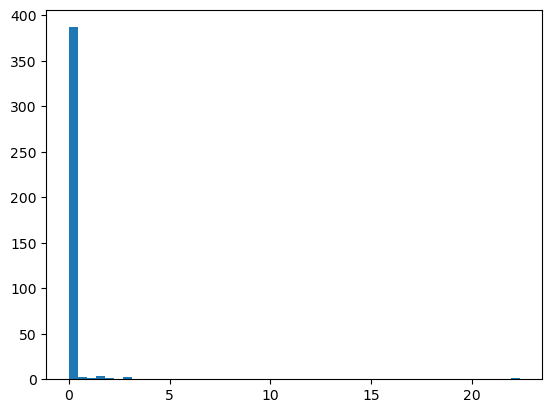

In [11]:
# plot the distribution of weights
import matplotlib.pyplot as plt
plt.hist(weights_sorted, bins=50)

(array([0.00280494, 0.00280494, 0.00490864, 0.00631111, 0.00911604,
        0.01823209, 0.01542715, 0.02173825, 0.02594567, 0.03015306,
        0.03365923, 0.03225677, 0.01963455, 0.02314072, 0.01753085,
        0.00771357, 0.00560987, 0.00140247, 0.00070123, 0.00140247]),
 array([-14.48699856, -10.92185497,  -7.35671139,  -3.79156804,
         -0.22642441,   3.33871913,   6.90386248,  10.46900654,
         14.03415012,  17.59929276,  21.16443634,  24.72957993,
         28.29472351,  31.8598671 ,  35.42501068,  38.99015427,
         42.55529785,  46.12044144,  49.68558502,  53.25072861,
         56.81587219]),
 <BarContainer object of 20 artists>)

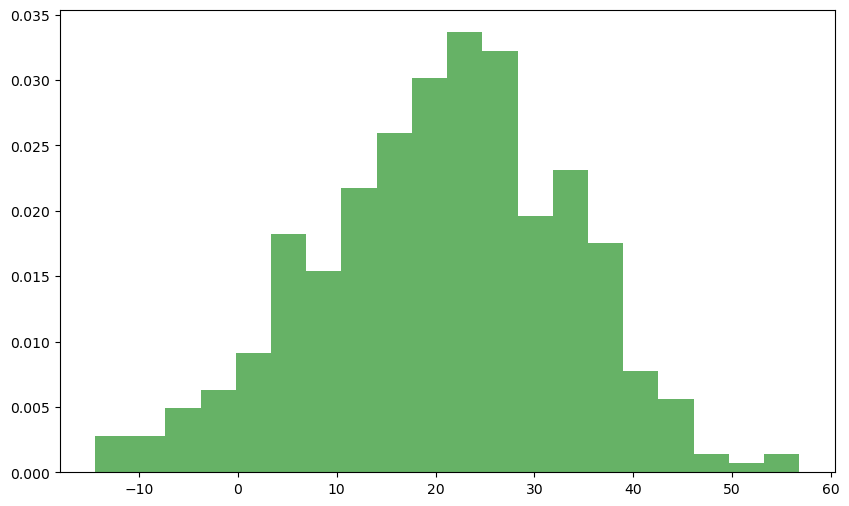

In [12]:
# plot the distribution of delta_reward
plt.figure(figsize=(10, 6))
plt.hist(reward, bins=20, density=True, alpha=0.6, color='g')

In [13]:
#calculate w(x,y) using calibration dataset

pi_b_diff = pickle.load(open("saved_trajectories/cal_0_diff.pkl", "rb"))
pi_b_0 = pickle.load(open("saved_trajectories/cal_0_o.pkl", "rb"))

pi_b_diff_trajs = pi_b_diff['trajectories']
pi_b_diff_actions = pi_b_diff['actions_trajectories']
pi_b_diff_rewards = pi_b_diff['rewards']
pi_b_0_trajs = pi_b_0['trajectories']
pi_b_0_actions = pi_b_0['actions_trajectories']
pi_b_0_rewards = pi_b_0['rewards']

# merge the two datasets
pi_b_whole_trajs = np.concatenate((pi_b_0_trajs, pi_b_diff_trajs), axis=0)
pi_b_whole_actions = np.concatenate((pi_b_0_actions, pi_b_diff_actions), axis=0)
pi_b_whole_rewards = np.concatenate((pi_b_0_rewards, pi_b_diff_rewards), axis=0)


In [14]:
def w(x, y):
    matching_pairs = []
    for i1 in range(len(pi_b_0_trajs)):
        if abs(pi_b_0_trajs[i1][0] - x) < eps_s and \
            abs(pi_b_0_rewards[i1] - y) < eps_r:
            matching_pairs.append(i1)
    w = 0
    n = len(matching_pairs)
    for i in matching_pairs:
        w1 = 1
        for t in range(len(pi_b_0_trajs[i])):
            w1 *= pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_b.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
            # w1 *= pi_n_10_1.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / \
            #     pi_u_0_10.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
        w += w1
    if n > 0:
        return w/n
    else:
        return -1

In [15]:
start_s = 5
# construct conformal prediction interval with level alpha
alpha = 0.2
# search for valid y from -10 to 10
y_list = np.linspace(-100, 100, 1000)
CP_1_y = []
for y in y_list:
    w_ = w(start_s, y)
    if w_ != -1:
        # check whether y is in (alpha/2, 1-alpha/2) quantile of F
        new_weights = np.append(weights_sorted, w_)
        normalized_weights = new_weights / np.sum(new_weights)
        # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
        low_level = 0
        high_level = 0
        low_q = 0
        high_q = 0
        for i in range(len(reward_sorted)):
            low_level += normalized_weights[i]
            if low_level >= alpha/2:
                low_q = reward_sorted[i-1]
                break
        for i in range(len(reward_sorted)):
            high_level += normalized_weights[i]
            if high_level >= 1 - alpha/2:
                high_q = reward_sorted[i-1]
                break
        print("y: ", y, "low_q: ", low_q, "high_q: ", high_q)
        # break
        # if low_q <= y <= high_q:
        #     CP_1_y.append(y)



y:  14.314314314314316 low_q:  21.239101 high_q:  37.782166
y:  14.514514514514516 low_q:  21.239101 high_q:  37.782166
y:  14.714714714714717 low_q:  21.239101 high_q:  37.782166
y:  18.71871871871872 low_q:  21.239101 high_q:  37.782166
y:  18.91891891891892 low_q:  21.239101 high_q:  37.782166
y:  19.11911911911912 low_q:  21.239101 high_q:  37.782166
y:  21.121121121121135 low_q:  21.239101 high_q:  37.782166
y:  21.321321321321335 low_q:  21.239101 high_q:  37.782166
y:  21.521521521521535 low_q:  21.239101 high_q:  37.782166
y:  26.126126126126138 low_q:  21.239101 high_q:  37.782166
y:  26.32632632632634 low_q:  21.239101 high_q:  37.782166
y:  26.52652652652654 low_q:  21.239101 high_q:  37.782166
y:  29.529529529529526 low_q:  21.239101 high_q:  37.782166
y:  29.72972972972974 low_q:  21.239101 high_q:  37.782166
y:  29.929929929929926 low_q:  21.239101 high_q:  37.782166
y:  35.13513513513513 low_q:  21.239101 high_q:  37.782166
y:  35.335335335335344 low_q:  21.239101 high_q

In [16]:
# calculate the confidence interval
CP = (low_q, high_q)
print("CP: ", CP)

CP:  (21.239101, 37.782166)


In [ ]:
# evaluate the policies by MC for 1000 episodes
rewards_list = []
def evaluate_policy(env, policy, gamma, num_episodes=1000):
    total_reward = 0
    for _ in range(num_episodes):
        reward = 0
        s = np.array(start_s).reshape(1,)
        for h in range(env.H):
            a = policy.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            reward += r * (gamma ** h)
            s = s1
        rewards_list.append(reward)
        total_reward += reward
    return total_reward / num_episodes, rewards_list


v_pi_e, r_list = evaluate_policy(env, pi_e, gamma=gamma, num_episodes=10000)
print("v_pi_e: ", v_pi_e)

In [318]:
# calculate the percentage of rewards in CP
r_list = np.array(r_list)
r_list = r_list[r_list >= CP[0]]
r_list = r_list[r_list <= CP[1]]
percentage = len(r_list) / 10000
print("percentage: ", percentage)   

percentage:  0.8734


In [936]:
CP_list = []
values_list = []

In [937]:
for start_s in range(0, 11):
    # construct conformal prediction interval with level alpha
    alpha = 0.01
    # search for valid y from -10 to 10
    y_list = np.linspace(-10, 10, 100)
    CP_1_y = []
    for y in y_list:
        w_ = w(start_s, y)
        if w_ > 0:
            # check whether y is in (alpha/2, 1-alpha/2) quantile of F
            new_weights = np.append(weights_sorted, w_)
            normalized_weights = new_weights / np.sum(new_weights)
            # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
            low_level = 0
            high_level = 0
            low_q = 0
            high_q = 0
            for i in range(len(delta_reward_sorted)):
                low_level += normalized_weights[i]
                if low_level >= alpha/2:
                    low_q = delta_reward_sorted[i-1]
                    break
            for i in range(len(delta_reward_sorted)):
                high_level += normalized_weights[i]
                if high_level >= 1 - alpha/2:
                    high_q = delta_reward_sorted[i-1]
                    break
            print("low_q: ", low_q)
            print("high_q: ", high_q)
            break
        
    # generate 500 trajectories from pi_n_10_1, saved as first_term
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = np.array(start_s).reshape(1,)
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_n_10_1.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)

    # convert to dictionary
    import pickle
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }

    # save as 9_first_term.pkl
    with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
        pickle.dump(data, f)

    pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

    pi_e_diff_trajs = pi_e_diff['trajectories']
    pi_e_diff_actions = pi_e_diff['actions']
    pi_e_diff_rewards = pi_e_diff['rewards']

    hat_V_pi_e = np.mean(pi_e_diff_rewards)

    CP = (np.mean(pi_e_diff_rewards) + low_q, np.mean(pi_e_diff_rewards) + high_q)
    print("CP: ", CP)

    # evaluate the policies by MC for 1000 episodes
    def evaluate_policy(env, policy, gamma, num_episodes=1000):
        total_reward = 0
        for _ in range(num_episodes):
            s = np.array(start_s).reshape(1,)
            for h in range(env.H):
                a = policy.act(s)
                s, a, r, s1, done = env.step(s, a, h)
                total_reward += r * (gamma ** h)
                s = s1
        return total_reward / num_episodes


    values = {}
    # policies = [pi_u_0_10, pi_u_0_5, pi_u_3_8, pi_u_0_0, pi_u_6_6,
                # pi_sS_3_10, pi_sS_3_6, pi_sS_7_10, pi_sS_1_5, pi_sS_5_8]
    policies = [pi_n_10_1]
    for policy in policies:
        policy_name = str(policy.__class__.__name__) + '_' + str(policy.mu) + '_' + str(policy.sigma)
        values[policy_name] = evaluate_policy(env, policy, gamma=0.9, num_episodes=10000)
        print(f"Policy: {policy_name}, Value: {values[policy_name]}")
    
    CP_list.append(CP)
    values_list.append(values[policy_name])

low_q:  -27.158
high_q:  1.3986043
CP:  (36.44493393417871, 65.00153915401971)
Policy: normal_policy_5.5_1, Value: 55.03128469808284
low_q:  -27.158
high_q:  1.3986043
CP:  (36.754131006989766, 65.31073622683077)
Policy: normal_policy_5.5_1, Value: 55.15667364162071
low_q:  -27.158
high_q:  1.3986043
CP:  (37.158600214359566, 65.71520543420057)
Policy: normal_policy_5.5_1, Value: 55.17581568814847
low_q:  -27.158
high_q:  1.3986043
CP:  (37.231689722219514, 65.78829494206052)
Policy: normal_policy_5.5_1, Value: 55.39566125079199
low_q:  -27.158
high_q:  1.3986043
CP:  (36.676116213079034, 65.23272143292004)
Policy: normal_policy_5.5_1, Value: 55.41238129700306
low_q:  -23.69566
high_q:  0
CP:  (40.98582414555793, 64.6814837830091)
Policy: normal_policy_5.5_1, Value: 55.61666380686406
low_q:  -27.158
high_q:  1.3986043
CP:  (37.10469276979396, 65.66129798963496)
Policy: normal_policy_5.5_1, Value: 55.29688514662465
low_q:  -27.158
high_q:  1.3986043
CP:  (35.01978110407971, 63.576386323

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_67607/4003381284.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '$V^{\\pi_e}(s_0)$')

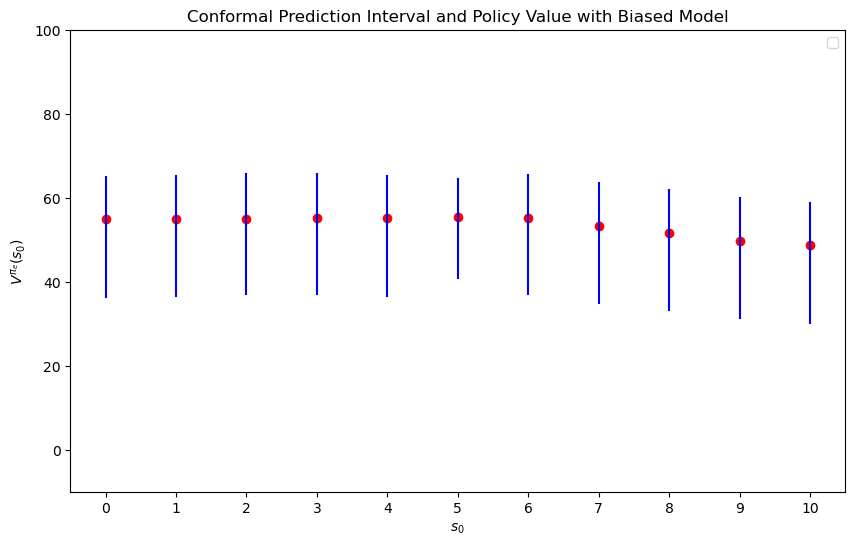

In [938]:
# plot the CP and values
# x-axis: start_s
# y-axis: dot is the value of policy, the interval is the CP
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(range(11), values_list, color='red')
for i in range(len(CP_list)):
    plt.plot([i, i], [CP_list[i][0], CP_list[i][1]], color='blue')
plt.title('Conformal Prediction Interval and Policy Value with Biased Model')
plt.legend()
plt.xticks(range(11))
# y-axis range (0, 100)
plt.ylim(-10, 100)
plt.xlabel('$s_0$')
plt.ylabel('$V^{\pi_e}(s_0)$')


In [897]:
CP_list = []
values_list = []

for start_s in range(0, 11):
    # construct conformal prediction interval with level alpha
    alpha = 0.2
    # search for valid y from -10 to 10
    y_list = np.linspace(-10, 10, 100)
    CP_1_y = []
    for y in y_list:
        w_ = w(start_s, y)
        if w_ > 0:
            # check whether y is in (alpha/2, 1-alpha/2) quantile of F
            new_weights = np.append(weights_sorted, w_)
            normalized_weights = new_weights / np.sum(new_weights)
            # calculate the quantile of the CDF F = \sum w_i * 1(x \le x_i)
            low_level = 0
            high_level = 0
            low_q = 0
            high_q = 0
            for i in range(len(delta_reward_sorted)):
                low_level += normalized_weights[i]
                if low_level >= alpha/2:
                    low_q = delta_reward_sorted[i-1]
                    break
            for i in range(len(delta_reward_sorted)):
                high_level += normalized_weights[i]
                if high_level >= 1 - alpha/2:
                    high_q = delta_reward_sorted[i-1]
                    break
            print("low_q: ", low_q)
            print("high_q: ", high_q)
            break
        
    # generate 500 trajectories from pi_n_10_1, saved as first_term
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = np.array(start_s).reshape(1,)
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_n_10_1.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)

    # convert to dictionary
    import pickle
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }

    # save as 9_first_term.pkl
    with open('saved_trajectories/9_first_term.pkl', 'wb') as f:
        pickle.dump(data, f)

    pi_e_diff = pickle.load(open("saved_trajectories/9_first_term.pkl", "rb"))

    pi_e_diff_trajs = pi_e_diff['trajectories']
    pi_e_diff_actions = pi_e_diff['actions']
    pi_e_diff_rewards = pi_e_diff['rewards']

    hat_V_pi_e = np.mean(pi_e_diff_rewards)

    CP = (np.mean(pi_e_diff_rewards) + low_q, np.mean(pi_e_diff_rewards) + high_q)
    print("CP: ", CP)

    # evaluate the policies by MC for 1000 episodes
    def evaluate_policy(env, policy, gamma, num_episodes=1000):
        total_reward = 0
        for _ in range(num_episodes):
            s = np.array(start_s).reshape(1,)
            for h in range(env.H):
                a = policy.act(s)
                s, a, r, s1, done = env.step(s, a, h)
                total_reward += r * (gamma ** h)
                s = s1
        return total_reward / num_episodes


    values = {}
    # policies = [pi_u_0_10, pi_u_0_5, pi_u_3_8, pi_u_0_0, pi_u_6_6,
                # pi_sS_3_10, pi_sS_3_6, pi_sS_7_10, pi_sS_1_5, pi_sS_5_8]
    policies = [pi_n_10_1]
    for policy in policies:
        policy_name = str(policy.__class__.__name__) + '_' + str(policy.mu) + '_' + str(policy.sigma)
        values[policy_name] = evaluate_policy(env, policy, gamma=0.9, num_episodes=10000)
        print(f"Policy: {policy_name}, Value: {values[policy_name]}")
    
    CP_list.append(CP)
    values_list.append(values[policy_name])

low_q:  -8.106695
high_q:  7.473574
CP:  (47.369689673603325, 62.949959010303765)
Policy: normal_policy_5.5_1, Value: 55.18755592713416
low_q:  -8.106695
high_q:  7.473574
CP:  (47.59108319967403, 63.17135253637447)
Policy: normal_policy_5.5_1, Value: 55.222578684828456
low_q:  -8.106695
high_q:  7.473574
CP:  (46.721522639374456, 62.301791976074895)
Policy: normal_policy_5.5_1, Value: 55.147819198332904
low_q:  -8.106695
high_q:  7.473574
CP:  (47.24277583189748, 62.82304516859792)
Policy: normal_policy_5.5_1, Value: 55.333938456858775
low_q:  -8.106695
high_q:  7.473574
CP:  (47.57476153062232, 63.15503086732276)
Policy: normal_policy_5.5_1, Value: 55.42158916201716
low_q:  -8.106695
high_q:  7.473574
CP:  (47.690738900516806, 63.271008237217245)
Policy: normal_policy_5.5_1, Value: 55.65182137712749
low_q:  -8.106695
high_q:  7.473574
CP:  (47.39073725416909, 62.97100659086953)
Policy: normal_policy_5.5_1, Value: 55.09866321565332
low_q:  -8.106695
high_q:  7.473574
CP:  (45.52670906

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_67607/3851528173.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, '$V^{\\pi_e}(s_0)$')

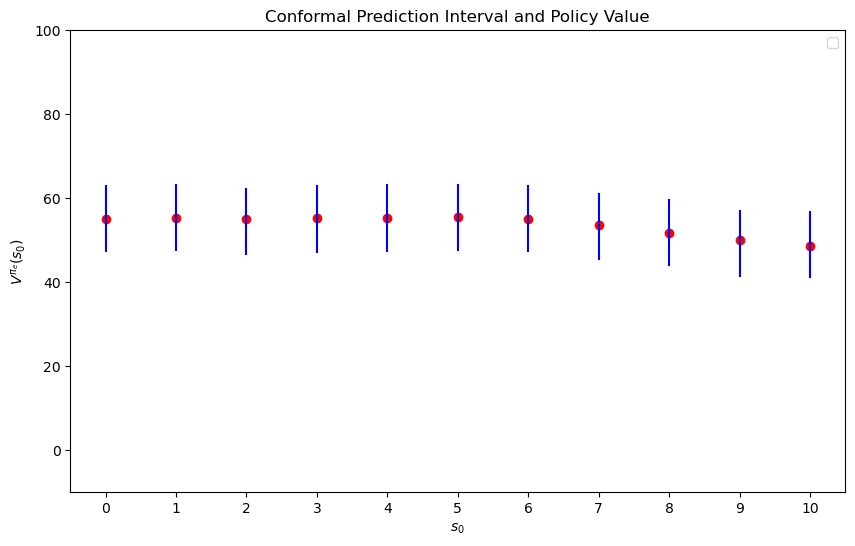

In [898]:
# plot the CP and values
# x-axis: start_s
# y-axis: dot is the value of policy, the interval is the CP
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(range(11), values_list, color='red')
for i in range(len(CP_list)):
    plt.plot([i, i], [CP_list[i][0], CP_list[i][1]], color='blue')
plt.title('Conformal Prediction Interval and Policy Value')
plt.legend()
plt.xticks(range(11))
# y-axis range (0, 100)
plt.ylim(-10, 100)
plt.xlabel('$s_0$')
plt.ylabel('$V^{\pi_e}(s_0)$')


In [17]:
# evaluate the policies by MC for 10000 episodes
def evaluate_policy(env, policy, gamma, num_episodes=1000):
    total_reward = 0
    for _ in range(num_episodes):
        # s = env.reset()
        s = np.array(start_s).reshape(1,)
        for h in range(env.H):
            a = policy.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            total_reward += r * (gamma ** h)
            s = s1
    return total_reward / num_episodes

# load the result from result.csv
result = pd.read_csv('saved_trajectories/result_per_state_5.csv')

V_list = []
V_up_list = []
V_low_list = []

for delta in np.linspace(0, 0.1, 10, endpoint=False):
    approximate_pi_u_0_10 = approximate_uniform_policy(0, 10, delta)
    pi_e = approximate_pi_u_0_10

    V_pi_e = evaluate_policy(env, pi_e, gamma=0.9, num_episodes=10000)
    V_delta_LB = result[result['delta'] == delta]['lower_bound'].values[0]
    V_delta_UB = result[result['delta'] == delta]['upper_bound'].values[0]
    V_list.append(V_pi_e)
    V_up_list.append(V_delta_UB)
    V_low_list.append(V_delta_LB)

Text(0.5, 0, '$d(\\pi_b, \\pi_e)$')

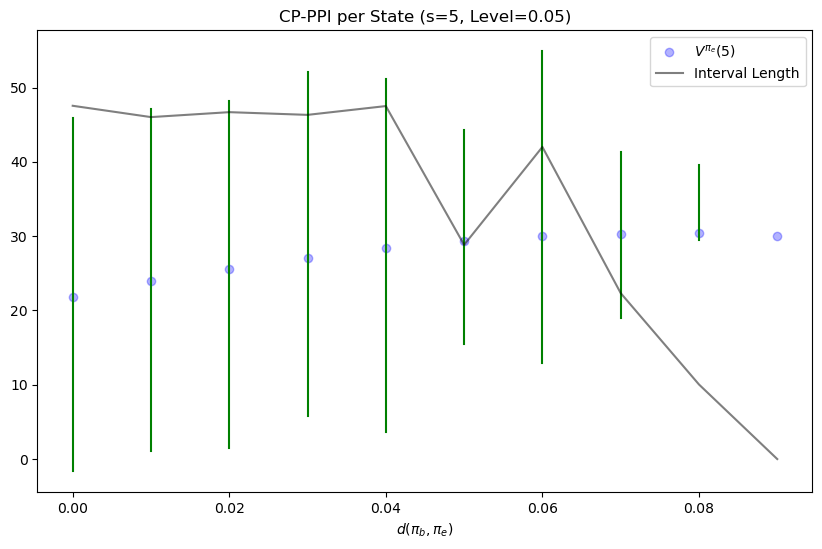

In [19]:
# plot the CP and values
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(np.linspace(0, 0.1, 10, endpoint=False), V_list, color='blue', alpha=0.3, label='$V^{\pi_e}(5)$')
for i in np.linspace(0, 0.1, 10, endpoint=False):
    if V_low_list[int(i*100)] <= V_list[int(i*100)] <= V_up_list[int(i*100)]:
        plt.plot([i, i], [V_low_list[int(i*100)], V_up_list[int(i*100)]], color='green')
    else:
        plt.plot([i, i], [V_low_list[int(i*100)], V_up_list[int(i*100)]], color='red')
interval_length = np.array(V_up_list) - np.array(V_low_list)
plt.plot(np.linspace(0, 0.1, 10, endpoint=False), interval_length, color='black', alpha=0.5, label='Interval Length')
plt.legend()
plt.title('CP-PPI per State (s=5, Level=0.05)')
plt.xlabel('$d(\pi_b, \pi_e)$')